# Titanic 17: ProfessionGroup

가설: 이름에서 추출한 직업·사회적 역할 호칭이 생존 여부에 추가 정보를 제공할 수 있다.

Base Model의 분할·결측치 처리·인코딩·CatBoost 설정을 유지하고 **Base + ProfessionGroup 하나**만 비교합니다. `FamilySize`, `IsAlone`은 유지하며 이전 실험의 interaction 피처는 사용하지 않습니다.

## 1. 데이터 불러오기와 Target 확인

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from common.utils import train_test_split_by_target
from common.title_feature_experiments import (
    NOBLE_TITLES, TitleFeaturePreprocessor, extract_title,
    make_profession_group, fit_feature_model, model_metrics, five_fold_compare,
)

ROOT = Path.cwd()
TRAIN_PATH = ROOT / "csv" / "train.csv"
TEST_PATH = ROOT / "csv" / "test.csv"
SUBMISSION_PATH = ROOT / "csv" / "submission.csv"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUBMISSION_PATH)

target_col = next(col for col in train.columns if col not in test.columns)
id_col = submission.columns[0]
feature_name = "ProfessionGroup"
print("train:", train.shape, "test:", test.shape, "submission:", submission.shape)
print("target:", target_col, "ID:", id_col, "candidate:", feature_name)

train: (916, 12) test: (393, 11) submission: (393, 2)
target: survived ID: passengerid candidate: ProfessionGroup


## 2. Base와 동일한 Train/Validation 분할

In [5]:
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]

assert set(y.unique()) == {0, 1}
assert X.columns.equals(X_test_raw.columns)
assert len(train_part) == 687 and len(valid_part) == 229
print("train split:", X_tr_raw.shape, "validation split:", X_valid_raw.shape)
print(y_tr.value_counts(normalize=True).sort_index().to_string())

train split: (687, 10) validation split: (229, 10)
survived
0    0.621543
1    0.378457


ValueError: could not convert string to float: 'Aks, Master. Philip Frank'

## 3. EDA — Title과 Target의 관계

EDA도 validation/test를 보지 않고 학습 부분만 사용합니다.

In [ ]:
titles = extract_title(train_part)
eda = pd.DataFrame({"Title": titles, target_col: y_tr})
eda["ProfessionGroup"] = eda["Title"].map(make_profession_group)

print("[전체 Title value_counts]")
print(eda["Title"].value_counts().to_string())
print("\n[ProfessionGroup별 count / survived mean]")
group_summary = eda.groupby("ProfessionGroup")[target_col].agg(["count", "mean"]).sort_index()
print(group_summary.to_string())
print("\n[각 ProfessionGroup에 포함된 실제 Title]")
included_titles = eda.groupby("ProfessionGroup")["Title"].apply(lambda values: sorted(values.unique()))
print(included_titles.to_string())
non_other_counts = group_summary.drop(index="Other", errors="ignore")["count"]
candidate_group_min_count = int(non_other_counts.min()) if len(non_other_counts) else 0
print(f"\n가장 작은 직업 그룹 표본 수: {candidate_group_min_count}명")

[전체 Title value_counts]
Title
Mr              393
Miss            139
Mrs             100
Master           36
Rev               5
Dr                4
Col               3
Major             2
Jonkheer          1
Don               1
the Countess      1
Sir               1
Capt              1

[ProfessionGroup별 count / survived mean]
                 count      mean
ProfessionGroup                 
Clergy               5  0.000000
Medical              4  0.250000
Military             6  0.166667
Other              672  0.383929

[각 ProfessionGroup에 포함된 실제 Title]
ProfessionGroup
Clergy                                                  [Rev]
Medical                                                  [Dr]
Military                                   [Capt, Col, Major]
Other       [Don, Jonkheer, Master, Miss, Mr, Mrs, Sir, th...

가장 작은 직업 그룹 표본 수: 4명


`Medical`, `Clergy`, `Military`, `Other`는 요청된 고정 규칙으로 생성합니다. 작은 직업 그룹의 생존율은 표본 몇 명에 따라 크게 달라질 수 있으며, validation 결과를 보고 분류 규칙을 바꾸지 않습니다.

## 4. 전처리와 Feature 생성

Base의 `FamilySize`, `IsAlone`을 유지합니다. `ProfessionGroup`만 새로 추가하고 `Title`, `name`, `ticket` 원문은 모델에서 제외합니다. 결측치 통계와 One-Hot Encoder는 학습 부분에서만 fit합니다.

In [ ]:
base_prep = TitleFeaturePreprocessor()
candidate_prep = TitleFeaturePreprocessor("ProfessionGroup")
X_base_train = base_prep.fit_transform(X_tr_raw)
X_base_valid = base_prep.transform(X_valid_raw)
X_candidate_train = candidate_prep.fit_transform(X_tr_raw)
X_candidate_valid = candidate_prep.transform(X_valid_raw)

assert X_base_train.columns.equals(X_base_valid.columns)
assert X_candidate_train.columns.equals(X_candidate_valid.columns)
assert not any(name.startswith("GenderClass") or name.startswith("GenderIsChild") or name.startswith("ClassIsChild") for name in X_candidate_train.columns)
assert "Title" not in X_candidate_train.columns
added_columns = [col for col in X_candidate_train.columns if col not in X_base_train.columns]
print("Base shape:", X_base_train.shape)
print("Candidate shape:", X_candidate_train.shape)
print("추가된 모델 입력 열:", added_columns)
print("Base에 유지된 파생 피처:", [col for col in ["FamilySize", "IsAlone"] if col in X_candidate_train.columns])
print("범주형 fit 대상:", candidate_prep.cat_cols_)
print("Scaling: 적용하지 않음 (Base Model과 동일)")

Base shape: (687, 12)
Candidate shape: (687, 16)
추가된 모델 입력 열: ['ProfessionGroup_Clergy', 'ProfessionGroup_Medical', 'ProfessionGroup_Military', 'ProfessionGroup_Other']
Base에 유지된 파생 피처: ['FamilySize', 'IsAlone']
범주형 fit 대상: ['gender', 'embarked', 'ProfessionGroup']
Scaling: 적용하지 않음 (Base Model과 동일)


## 5. 동일 Holdout에서 Base와 Candidate 학습

두 모델은 seed 42와 Base CatBoost 설정을 그대로 사용하며 실효 파라미터 전체가 같은지 검증합니다.

In [ ]:
_, base_model, X_base_train, X_base_valid = fit_feature_model(X_tr_raw, y_tr, X_valid_raw, None)
_, candidate_model, X_candidate_train, X_candidate_valid = fit_feature_model(X_tr_raw, y_tr, X_valid_raw, feature_name)
assert base_model.get_all_params() == candidate_model.get_all_params()

base_result = model_metrics(base_model, X_base_train, y_tr, X_base_valid, y_valid)
candidate_result = model_metrics(candidate_model, X_candidate_train, y_tr, X_candidate_valid, y_valid)

def classification_metrics(result):
    prediction = result["valid_prediction"]
    tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_valid, prediction),
        "precision": precision_score(y_valid, prediction, zero_division=0),
        "recall": recall_score(y_valid, prediction, zero_division=0),
        "f1": f1_score(y_valid, prediction, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

base_class = classification_metrics(base_result)
candidate_class = classification_metrics(candidate_result)
print("Base CatBoost params:", base_model.get_params())
print("Candidate CatBoost params:", candidate_model.get_params())
print("실효 파라미터 전체 일치:", base_model.get_all_params() == candidate_model.get_all_params())

Base CatBoost params: {'verbose': 0, 'allow_writing_files': False, 'random_state': 42, 'cat_features': []}
Candidate CatBoost params: {'verbose': 0, 'allow_writing_files': False, 'random_state': 42, 'cat_features': []}
실효 파라미터 전체 일치: True


## 6. 5-Fold Cross Validation

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`를 사용합니다. 각 fold 안에서 전처리와 인코딩을 다시 학습해 누수를 막습니다.

In [ ]:
fold_table, cv_summary = five_fold_compare(X, y, feature_name)
fold_pivot = fold_table.pivot(index="fold", columns="model", values="auc")
fold_pivot["Difference"] = fold_pivot["Candidate"] - fold_pivot["Base"]
improved_folds = int((fold_pivot["Difference"] > 0).sum())
print("\n[5-Fold AUC]")
print(fold_pivot.to_string(float_format=lambda value: f"{value:.6f}"))
print("\n[CV 요약]")
print(cv_summary.to_string(float_format=lambda value: f"{value:.6f}"))
print(f"Candidate가 개선된 fold: {improved_folds}/5")

Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료

[5-Fold AUC]
model     Base  Candidate  Difference
fold                                 
1     0.891917   0.890664   -0.001253
2     0.919082   0.917684   -0.001398
3     0.878782   0.876112   -0.002670
4     0.906433   0.907958    0.001526
5     0.912662   0.910628   -0.002034

[CV 요약]
              mean      std
model                      
Base      0.901775 0.016322
Candidate 0.900609 0.016918
Candidate가 개선된 fold: 1/5


## 7. Base vs Candidate 비교

In [ ]:
metrics = ["Train AUC", "Validation AUC", "Gap", "CV Mean", "CV Std", "Accuracy", "Precision", "Recall", "F1"]
base_values = [
    base_result["train_auc"], base_result["validation_auc"], base_result["gap"],
    cv_summary.loc["Base", "mean"], cv_summary.loc["Base", "std"],
    base_class["accuracy"], base_class["precision"], base_class["recall"], base_class["f1"],
]
candidate_values = [
    candidate_result["train_auc"], candidate_result["validation_auc"], candidate_result["gap"],
    cv_summary.loc["Candidate", "mean"], cv_summary.loc["Candidate", "std"],
    candidate_class["accuracy"], candidate_class["precision"], candidate_class["recall"], candidate_class["f1"],
]
comparison = pd.DataFrame({"Metric": metrics, "Base": base_values, "Candidate": candidate_values})
comparison["Difference"] = comparison["Candidate"] - comparison["Base"]
print(comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

holdout_up = candidate_result["validation_auc"] > base_result["validation_auc"]
cv_up = cv_summary.loc["Candidate", "mean"] > cv_summary.loc["Base", "mean"]
fold_consistent = improved_folds >= 3
std_stable = cv_summary.loc["Candidate", "std"] <= cv_summary.loc["Base", "std"] + 0.005
gap_stable = candidate_result["gap"] <= base_result["gap"] + 0.01
performance_pass = holdout_up and cv_up and fold_consistent and std_stable and gap_stable
small_sample = candidate_group_min_count < 30
if performance_pass and not small_sample:
    decision = "채택"
elif performance_pass and small_sample:
    decision = "추가 검증 필요"
else:
    decision = "제외"
print("\n판단 조건:", {"holdout_up": holdout_up, "cv_up": cv_up, "improved_folds": improved_folds,
                         "std_stable": std_stable, "gap_stable": gap_stable,
                         "small_sample": small_sample})
print("최종 판단:", decision)

        Metric     Base  Candidate  Difference
     Train AUC 0.963079   0.962182   -0.000896
Validation AUC 0.900065   0.899496   -0.000569
           Gap 0.063014   0.062687   -0.000327
       CV Mean 0.901775   0.900609   -0.001166
        CV Std 0.016322   0.016918    0.000597
      Accuracy 0.860262   0.864629    0.004367
     Precision 0.829268   0.839506    0.010238
        Recall 0.790698   0.790698    0.000000
            F1 0.809524   0.814371    0.004847

판단 조건: {'holdout_up': False, 'cv_up': np.False_, 'improved_folds': 1, 'std_stable': np.True_, 'gap_stable': True, 'small_sample': True}
최종 판단: 제외


## 8. Validation Confusion Matrix

<string>:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
Base: {'accuracy': 0.8602620087336245, 'precision': 0.8292682926829268, 'recall': 0.7906976744186046, 'f1': 0.8095238095238095, 'tn': 129, 'fp': 14, 'fn': 18, 'tp': 68}
Candidate: {'accuracy': 0.8646288209606987, 'precision': 0.8395061728395061, 'recall': 0.7906976744186046, 'f1': 0.8143712574850299, 'tn': 130, 'fp': 13, 'fn': 18, 'tp': 68}


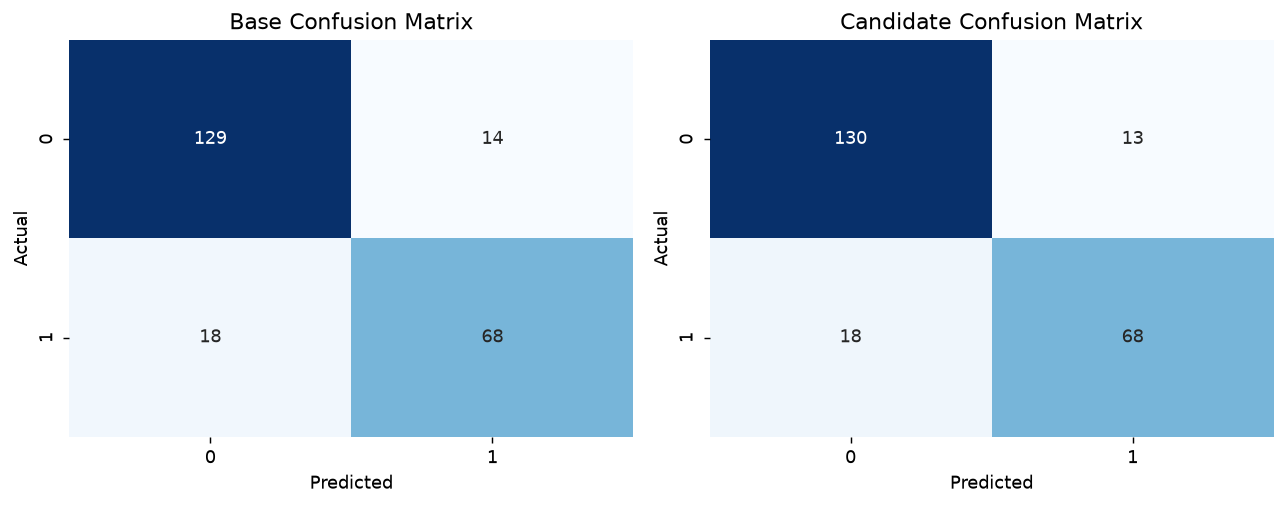

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, label, result in zip(axes, ["Base", "Candidate"], [base_result, candidate_result]):
    matrix = confusion_matrix(y_valid, result["valid_prediction"], labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(f"{label} Confusion Matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()
print("Base:", base_class)
print("Candidate:", candidate_class)

## 9. 전체 Train/Test 전처리 연결 검증

제출 파일은 만들지 않고, 최종 학습 시 사용할 전체 train fit → test transform 흐름만 검증합니다.

In [ ]:
full_candidate_prep = TitleFeaturePreprocessor("ProfessionGroup")
X_full_candidate = full_candidate_prep.fit_transform(X)
X_test_candidate = full_candidate_prep.transform(X_test_raw)
assert X_full_candidate.columns.equals(X_test_candidate.columns)
assert np.isfinite(X_full_candidate.to_numpy()).all()
assert np.isfinite(X_test_candidate.to_numpy()).all()
print("전체 train/test 변환 검증 완료:", X_full_candidate.shape, X_test_candidate.shape)
print("encoder는 전체 train에 fit되고 test에는 transform만 적용됨")

전체 train/test 변환 검증 완료: (916, 16) (393, 16)
encoder는 전체 train에 fit되고 test에는 transform만 적용됨


In [ ]:
conclusion_markdown = f"""## 실험 결론

### 가설
이름에서 추출한 직업·사회적 역할 호칭이 생존 여부에 추가 정보를 제공할 수 있다.

### 결과
- Base Validation AUC: {base_result['validation_auc']:.6f}
- Candidate Validation AUC: {candidate_result['validation_auc']:.6f}
- 변화: {candidate_result['validation_auc'] - base_result['validation_auc']:+.6f}
- Base CV Mean: {cv_summary.loc['Base', 'mean']:.6f}
- Candidate CV Mean: {cv_summary.loc['Candidate', 'mean']:.6f}
- 변화: {cv_summary.loc['Candidate', 'mean'] - cv_summary.loc['Base', 'mean']:+.6f}
- CV Std: Base {cv_summary.loc['Base', 'std']:.6f} / Candidate {cv_summary.loc['Candidate', 'std']:.6f}
- Gap: Base {base_result['gap']:.6f} / Candidate {candidate_result['gap']:.6f}
- 개선된 CV Fold: {improved_folds}/5

### Confusion Matrix 변화
- FP: {base_class['fp']} → {candidate_class['fp']} ({candidate_class['fp'] - base_class['fp']:+d})
- FN: {base_class['fn']} → {candidate_class['fn']} ({candidate_class['fn'] - base_class['fn']:+d})
- TP: {base_class['tp']} → {candidate_class['tp']} ({candidate_class['tp'] - base_class['tp']:+d})
- TN: {base_class['tn']} → {candidate_class['tn']} ({candidate_class['tn'] - base_class['tn']:+d})

### 해석
후보는 Base Model에 `ProfessionGroup` 하나만 추가했다. 같은 split과 같은 CatBoost 실효 파라미터로 비교했으며, 5-Fold CV도 각 fold의 학습 부분에서 전처리와 encoder를 새로 fit했다. 최소 관련 그룹 표본은 {candidate_group_min_count}명이다. 표본이 30명보다 작으면 일부 승객의 결과가 그룹 통계와 모델 평가를 크게 움직일 수 있으므로 성능 수치와 함께 신중하게 해석한다.

### 최종 판단
**{decision}**
"""
print(conclusion_markdown)

## 실험 결론

### 가설
이름에서 추출한 직업·사회적 역할 호칭이 생존 여부에 추가 정보를 제공할 수 있다.

### 결과
- Base Validation AUC: 0.900065
- Candidate Validation AUC: 0.899496
- 변화: -0.000569
- Base CV Mean: 0.901775
- Candidate CV Mean: 0.900609
- 변화: -0.001166
- CV Std: Base 0.016322 / Candidate 0.016918
- Gap: Base 0.063014 / Candidate 0.062687
- 개선된 CV Fold: 1/5

### Confusion Matrix 변화
- FP: 14 → 13 (-1)
- FN: 18 → 18 (+0)
- TP: 68 → 68 (+0)
- TN: 129 → 130 (+1)

### 해석
후보는 Base Model에 `ProfessionGroup` 하나만 추가했다. 같은 split과 같은 CatBoost 실효 파라미터로 비교했으며, 5-Fold CV도 각 fold의 학습 부분에서 전처리와 encoder를 새로 fit했다. 최소 관련 그룹 표본은 4명이다. 표본이 30명보다 작으면 일부 승객의 결과가 그룹 통계와 모델 평가를 크게 움직일 수 있으므로 성능 수치와 함께 신중하게 해석한다.

### 최종 판단
**제외**



## 실험 결론

### 가설
이름에서 추출한 직업·사회적 역할 호칭이 생존 여부에 추가 정보를 제공할 수 있다.

### 결과
- Base Validation AUC: 0.900065
- Candidate Validation AUC: 0.899496
- 변화: -0.000569
- Base CV Mean: 0.901775
- Candidate CV Mean: 0.900609
- 변화: -0.001166
- CV Std: Base 0.016322 / Candidate 0.016918
- Gap: Base 0.063014 / Candidate 0.062687
- 개선된 CV Fold: 1/5

### Confusion Matrix 변화
- FP: 14 → 13 (-1)
- FN: 18 → 18 (+0)
- TP: 68 → 68 (+0)
- TN: 129 → 130 (+1)

### 해석
후보는 Base Model에 `ProfessionGroup` 하나만 추가했다. 같은 split과 같은 CatBoost 실효 파라미터로 비교했으며, 5-Fold CV도 각 fold의 학습 부분에서 전처리와 encoder를 새로 fit했다. 최소 관련 그룹 표본은 4명이다. 표본이 30명보다 작으면 일부 승객의 결과가 그룹 통계와 모델 평가를 크게 움직일 수 있으므로 성능 수치와 함께 신중하게 해석한다.

### 최종 판단
**제외**
